**Практика 5**

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt


np.random.seed(42)
X = np.random.uniform(-3, 3, 100).reshape(-1, 1)
y = np.sin(X.ravel()) + np.random.normal(0, 0.2, 100)


splits = []
random_states = [10, 20, 30, 40, 50]

for rs in random_states:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rs)
    splits.append((X_train, X_test, y_train, y_test))

In [3]:


degrees = [1, 2, 3, 5, 10, 15]
all_predictions = {}

X_test_canonical = splits[0][1] 

for deg in degrees:
    poly = PolynomialFeatures(degree=deg)
    predictions_for_degree = []
    
    for X_train, X_test, y_train, y_test in splits:
      
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test_canonical)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train)
        
        y_pred = model.predict(X_test_poly)
        predictions_for_degree.append(y_pred)
        
    all_predictions[deg] = predictions_for_degree



In [5]:
y_test_true = splits[0][3] 
results = {}

for deg, preds in all_predictions.items():
    preds_array = np.array(preds) 
    
    mean_pred = np.mean(preds_array, axis=0)
    
    
    bias_squared = np.mean((mean_pred - y_test_true) ** 2)
    
   
    variance = np.mean(np.var(preds_array, axis=0))
    
    mse = np.mean((preds_array - y_test_true) ** 2)
    
    results[deg] = {'bias_sq': bias_squared, 'var': variance, 'mse': mse}
    print(f"Степень {deg}: Смещение** 2 = {bias_squared:.4f}, Дисперсия = {variance:.4f}, MSE = {mse:.4f}")

Степень 1: Смещение = 0.2006, Дисперсия = 0.0025, MSE = 0.2031
Степень 2: Смещение = 0.2021, Дисперсия = 0.0031, MSE = 0.2052
Степень 3: Смещение = 0.0367, Дисперсия = 0.0007, MSE = 0.0375
Степень 5: Смещение = 0.0370, Дисперсия = 0.0010, MSE = 0.0379
Степень 10: Смещение = 0.0356, Дисперсия = 0.0016, MSE = 0.0373
Степень 15: Смещение = 0.0358, Дисперсия = 0.0024, MSE = 0.0382


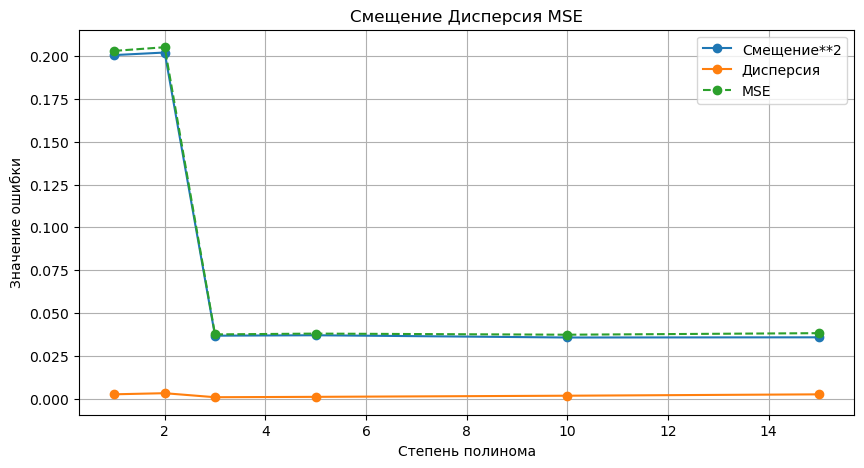

In [13]:

degs = list(results.keys())
plt.figure(figsize=(10, 5))
plt.plot(degs, [results[d]['bias_sq'] for d in degs], label='Смещение**2', marker='o')
plt.plot(degs, [results[d]['var'] for d in degs], label='Дисперсия', marker='o')
plt.plot(degs, [results[d]['mse'] for d in degs], label='MSE', linestyle='--', marker='o')
plt.title('Смещение Дисперсия MSE')
plt.xlabel('Степень полинома')
plt.ylabel('Значение ошибки')
plt.legend()
plt.grid(True)
plt.show()


